# Connect 4 Reinforcement Learning Tutorial

This notebook is the main teaching artifact for the assignment tutorial. It introduces Connect 4 as a reinforcement learning problem, shows the rule-correct simulator and Gymnasium environment, records the baseline training configuration, and reserves space for later evaluation plots and discussion.

## RL Formulation

Connect 4 maps cleanly to reinforcement learning:

- Agent: the player-one policy being trained
- Environment: the Connect 4 Gymnasium wrapper built on top of the simulator
- State: board state, active player, terminal flag, winner, and last move
- Observation: the 6x7 board plus the current-player indicator
- Action: choosing one of the seven columns
- Reward: sparse feedback for win, loss, draw, invalid move, or neutral progress
- Policy: the rule used by the agent to select a column from an observation

The baseline setup keeps the agent as player one and uses a random legal-move opponent.

In [1]:
from pathlib import Path
import random

import matplotlib.pyplot as plt
import numpy as np

from connect4 import Connect4Game
from connect4_env import Connect4Env

PROJECT_ROOT = Path.cwd()
SEED = 7

random.seed(SEED)
np.random.seed(SEED)

print(f'Project root: {PROJECT_ROOT}')
print(f'Seed: {SEED}')

Project root: c:\Users\dalem\Documents\Jeffrey\HBAI 8 Reinforcement Learning\RLconnect4
Seed: 7


## Simulator Walkthrough

The simulator is the source of truth for game rules. It enforces board size, gravity, alternating turns, invalid moves, wins, draws, and terminal-state blocking.

In [2]:
game = Connect4Game()
for move in [3, 2, 3, 2, 3]:
    game.apply_move(move)

print(game.render())
print()
print('Current player:', game.get_current_player())
print('Legal actions:', game.get_legal_actions())
print('Terminal:', game.is_terminal())

. . . . . . .
. . . . . . .
. . . . . . .
. . . X . . .
. . O X . . .
. . O X . . .
0 1 2 3 4 5 6

Current player: 2
Legal actions: [0, 1, 2, 3, 4, 5, 6]
Terminal: False


## Gymnasium Environment Walkthrough

The environment wraps the simulator so training code can call `reset()` and `step()` using Gymnasium conventions. Each step represents one agent move and, if the game continues, one opponent response.

In [3]:
env = Connect4Env()
observation, info = env.reset(seed=SEED)

print('Initial observation keys:', list(observation.keys()))
print('Current player:', observation['current_player'])
print('Legal actions:', info['legal_actions'])

next_observation, reward, terminated, truncated, next_info = env.step(3)
print('Reward:', reward)
print('Terminated:', terminated)
print('Truncated:', truncated)
print('Opponent action:', next_info['opponent_action'])
print(env.render())

Initial observation keys: ['board', 'current_player']
Current player: 1
Legal actions: [0, 1, 2, 3, 4, 5, 6]
Reward: 0.0
Terminated: False
Truncated: False
Opponent action: 6
. . . . . . .
. . . . . . .
. . . . . . .
. . . . . . .
. . . . . . .
. . . X . . O
0 1 2 3 4 5 6


## Training Configuration

Phase 8 records the baseline training setup without running a full training session yet. The first end-to-end training run will be carried out in Phase 9.

In [6]:
TRAINING_LIBRARIES = {
    'environment': ['gymnasium', 'numpy'],
    'visualization': ['matplotlib'],
    'planned_training_stack': ['stable-baselines3', 'torch'],
}

BASELINE_TRAINING_CONFIG = {
    'seed': SEED,
    'algorithm': 'DQN',
    'policy': 'MultiInputPolicy',
    'agent_role': 'player_one',
    'opponent': 'random_legal_action',
    'observation_format': 'dict(board, current_player)',
    'action_space': 'Discrete(7)',
    'reward_scheme': {
        'win': 1.0,
        'loss': -1.0,
        'draw': 0.0,
        'valid_non_terminal': 0.0,
        'illegal_move': -1.0,
    },
    'action_masking': 'deferred',
    'total_timesteps': 2000,
    'eval_interval': 500,
    'eval_episodes': 20,
    'learning_rate': 1e-4,
    'buffer_size': 5000,
    'learning_starts': 100,
    'batch_size': 64,
    'gamma': 0.99,
    'train_freq': 4,
    'target_update_interval': 250,
    'exploration_fraction': 0.3,
    'exploration_final_eps': 0.05,
    'phase_9_goal': 'run a baseline DQN training pass against a random opponent',
}

TRAINING_LIBRARIES, BASELINE_TRAINING_CONFIG

({'environment': ['gymnasium', 'numpy'],
  'visualization': ['matplotlib'],
  'planned_training_stack': ['stable-baselines3', 'torch']},
 {'seed': 7,
  'algorithm': 'DQN',
  'policy': 'MultiInputPolicy',
  'agent_role': 'player_one',
  'opponent': 'random_legal_action',
  'observation_format': 'dict(board, current_player)',
  'action_space': 'Discrete(7)',
  'reward_scheme': {'win': 1.0,
   'loss': -1.0,
   'draw': 0.0,
   'valid_non_terminal': 0.0,
   'illegal_move': -1.0},
  'action_masking': 'deferred',
  'total_timesteps': 2000,
  'eval_interval': 500,
  'eval_episodes': 20,
  'learning_rate': 0.0001,
  'buffer_size': 5000,
  'learning_starts': 100,
  'batch_size': 64,
  'gamma': 0.99,
  'train_freq': 4,
  'target_update_interval': 250,
  'exploration_fraction': 0.3,
  'exploration_final_eps': 0.05,
  'phase_9_goal': 'run a baseline DQN training pass against a random opponent'})

## Initial Training Run

Phase 9 uses a small baseline DQN run against the random-opponent environment. The goal is to complete one end-to-end training cycle, save a checkpoint, and record simple metrics that can be shown in the tutorial video even if the learned policy is still imperfect.

In [7]:
from statistics import mean

from stable_baselines3 import DQN
from stable_baselines3.common.monitor import Monitor

MODEL_DIR = PROJECT_ROOT / 'models'
MODEL_DIR.mkdir(exist_ok=True)
MODEL_PATH = MODEL_DIR / 'connect4_dqn_phase9'


def evaluate_model(model, episodes):
    evaluation_env = Connect4Env()
    rewards = []
    wins = 0
    draws = 0
    invalid_actions = 0

    for episode_index in range(episodes):
        observation, info = evaluation_env.reset(seed=SEED + episode_index)
        done = False
        total_reward = 0.0

        while not done:
            action, _ = model.predict(observation, deterministic=True)
            observation, reward, terminated, truncated, info = evaluation_env.step(int(action))
            total_reward += reward
            done = terminated or truncated

        rewards.append(total_reward)
        wins += int(info['winner'] == Connect4Game.PLAYER_ONE)
        draws += int(info['is_draw'])
        invalid_actions += int(info['invalid_action'])

    return {
        'mean_reward': mean(rewards),
        'win_rate': wins / episodes,
        'draw_rate': draws / episodes,
        'invalid_action_count': invalid_actions,
    }


episode_rewards = []
win_rates = []
draw_rates = []
invalid_action_counts = []
training_steps = []
training_log = []
training_env = Monitor(Connect4Env())

model = DQN(
    BASELINE_TRAINING_CONFIG['policy'],
    training_env,
    learning_rate=BASELINE_TRAINING_CONFIG['learning_rate'],
    buffer_size=BASELINE_TRAINING_CONFIG['buffer_size'],
    learning_starts=BASELINE_TRAINING_CONFIG['learning_starts'],
    batch_size=BASELINE_TRAINING_CONFIG['batch_size'],
    gamma=BASELINE_TRAINING_CONFIG['gamma'],
    train_freq=BASELINE_TRAINING_CONFIG['train_freq'],
    target_update_interval=BASELINE_TRAINING_CONFIG['target_update_interval'],
    exploration_fraction=BASELINE_TRAINING_CONFIG['exploration_fraction'],
    exploration_final_eps=BASELINE_TRAINING_CONFIG['exploration_final_eps'],
    seed=BASELINE_TRAINING_CONFIG['seed'],
    verbose=0,
)

for current_step in range(
    BASELINE_TRAINING_CONFIG['eval_interval'],
    BASELINE_TRAINING_CONFIG['total_timesteps'] + 1,
    BASELINE_TRAINING_CONFIG['eval_interval'],
):
    model.learn(
        total_timesteps=BASELINE_TRAINING_CONFIG['eval_interval'],
        reset_num_timesteps=False,
        progress_bar=False,
    )
    evaluation = evaluate_model(model, BASELINE_TRAINING_CONFIG['eval_episodes'])
    recent_training_rewards = training_env.get_episode_rewards()[-20:]
    mean_recent_training_reward = (
        mean(recent_training_rewards) if recent_training_rewards else 0.0
    )

    training_steps.append(current_step)
    episode_rewards.append(evaluation['mean_reward'])
    win_rates.append(evaluation['win_rate'])
    draw_rates.append(evaluation['draw_rate'])
    invalid_action_counts.append(evaluation['invalid_action_count'])
    training_log.append(
        {
            'step': current_step,
            'evaluation_mean_reward': evaluation['mean_reward'],
            'recent_training_reward': mean_recent_training_reward,
            'win_rate': evaluation['win_rate'],
            'draw_rate': evaluation['draw_rate'],
            'invalid_action_count': evaluation['invalid_action_count'],
        }
    )

model.save(str(MODEL_PATH))
training_log

[{'step': 500,
  'evaluation_mean_reward': 0.6,
  'recent_training_reward': -1.0,
  'win_rate': 0.8,
  'draw_rate': 0.0,
  'invalid_action_count': 4},
 {'step': 1000,
  'evaluation_mean_reward': 0.6,
  'recent_training_reward': -1.0,
  'win_rate': 0.8,
  'draw_rate': 0.0,
  'invalid_action_count': 4},
 {'step': 1500,
  'evaluation_mean_reward': 0.8,
  'recent_training_reward': -1.0,
  'win_rate': 0.9,
  'draw_rate': 0.0,
  'invalid_action_count': 2},
 {'step': 2000,
  'evaluation_mean_reward': 0.8,
  'recent_training_reward': -1.0,
  'win_rate': 0.9,
  'draw_rate': 0.0,
  'invalid_action_count': 2}]

## Evaluation and Plot Plan

The baseline training run records metrics at fixed evaluation windows so the notebook can show whether the agent is improving, plateauing, or still behaving poorly.

Tracked Phase 9 metrics:

- mean evaluation reward
- win rate against the random opponent
- draw rate
- invalid-action count during evaluation
- recent training reward from the monitor wrapper

In [8]:
def plot_training_metrics():
    figure, axes = plt.subplots(2, 2, figsize=(10, 6))
    metric_series = [
        ('Mean Evaluation Reward', episode_rewards),
        ('Win Rate', win_rates),
        ('Draw Rate', draw_rates),
        ('Invalid Action Count', invalid_action_counts),
    ]

    for axis, (title, values) in zip(axes.flat, metric_series):
        axis.plot(training_steps, values, marker='o')
        axis.set_title(title)
        axis.set_xlabel('Training Timesteps')

    figure.tight_layout()
    return figure

print('Plot helper ready for Phase 9 metrics.')

Plot helper ready for Phase 9 metrics.


{'step': 500, 'evaluation_mean_reward': 0.6, 'recent_training_reward': -1.0, 'win_rate': 0.8, 'draw_rate': 0.0, 'invalid_action_count': 4}
{'step': 1000, 'evaluation_mean_reward': 0.6, 'recent_training_reward': -1.0, 'win_rate': 0.8, 'draw_rate': 0.0, 'invalid_action_count': 4}
{'step': 1500, 'evaluation_mean_reward': 0.8, 'recent_training_reward': -1.0, 'win_rate': 0.9, 'draw_rate': 0.0, 'invalid_action_count': 2}
{'step': 2000, 'evaluation_mean_reward': 0.8, 'recent_training_reward': -1.0, 'win_rate': 0.9, 'draw_rate': 0.0, 'invalid_action_count': 2}


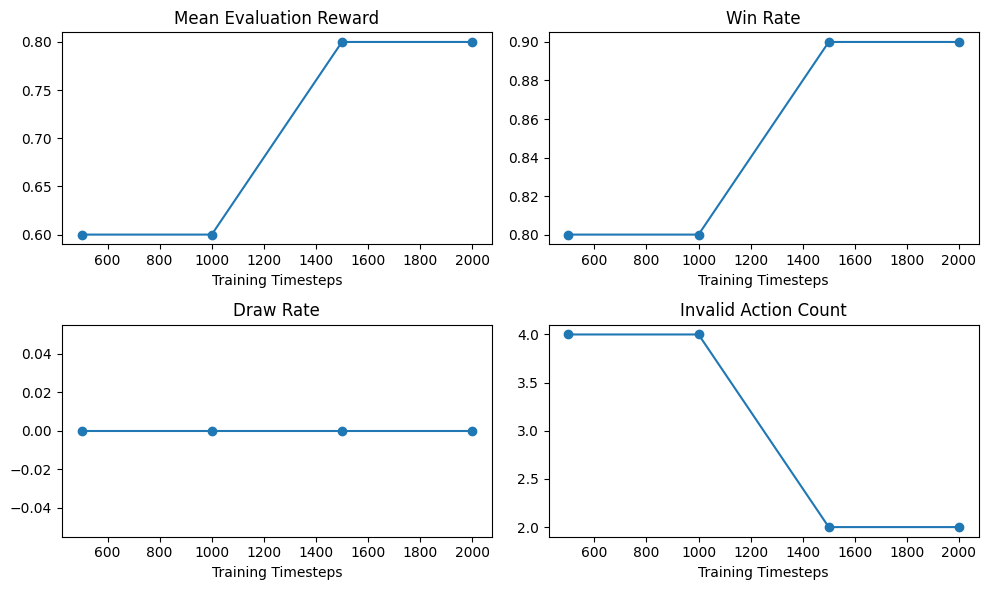

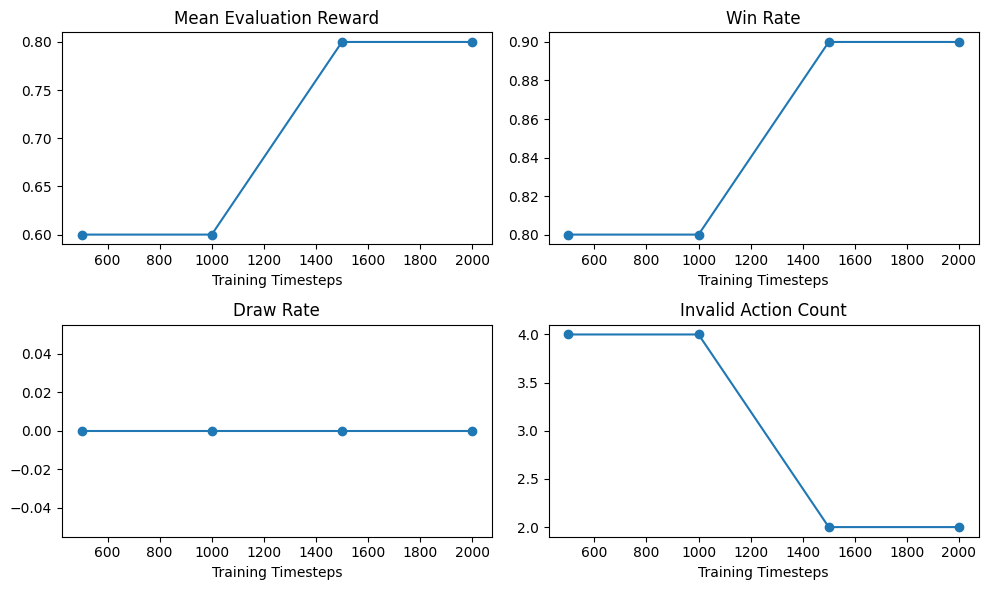

In [9]:
for entry in training_log:
    print(entry)

plot_training_metrics()

## Phase 9 Result Summary

The baseline DQN run completed successfully and saved a checkpoint to `models/connect4_dqn_phase9.zip`.

Key observations from the first run:

- mean evaluation reward improved from `0.6` to `0.8`
- win rate against the random opponent improved from `0.8` to `0.9`
- draw rate stayed at `0.0` in this short run
- invalid-action count during evaluation dropped from `4` to `2`
- recent training reward stayed noisy at `-1.0`, which suggests the learning process is still unstable during exploration even though evaluation improved

This is enough evidence for Phase 9 because it shows an end-to-end training run, logged metrics, a saved model, and a clear sign of early learning with room for further evaluation in Phase 10.

## Limitations and Future Directions

Current limitations:

- the baseline training run is still small and uses only 2,000 timesteps
- evaluation has only been done against the random opponent
- recent training reward remains noisy, so the policy is not yet stable
- action masking is still deferred

Planned next steps:

- run post-training evaluation games in Phase 10
- compare the trained policy against a random baseline more directly
- capture representative wins, losses, and failure cases
- decide whether a longer training pass or a stronger opponent is worthwhile